In [1]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.utils import load_config,check_file_exists,print_balancing, plot_confusion_ascii, write_time
from src.fancy_plots import build_cmap
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score


from typing import Any

from typing import Dict

In [2]:
from src.fancy_plots import build_cmap, gold_map
from seaborn import cm


In [3]:
# let's find the different files we need
config = load_config('config.yaml')
cf_results = config['paths']['counterfactuals']
dt_name = "german_credit"
name_dataset = {"german_credit": "German Credit", 
                "adult": "Adult",
                "toy_dataset":"Toy Dataset",
                }[dt_name]
cf_results

'counterfactuals/'

In [4]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed/german_credit/feature_names.csv
Loaded X_train from data/processed/german_credit/X_train.npz
Loaded y_train from data/processed/german_credit/y_train.npz
Loaded X_test from data/processed/german_credit/X_test.npz
Loaded y_test from data/processed/german_credit/y_test.npz
Loaded X_calibration from data/processed/german_credit/X_calibration.npz
Loaded y_calibration from data/processed/german_credit/y_calibration.npz


In [5]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for german_credit
Loaded random_forest model from models/german_credit/random_forest.pkl
Loaded existing random_forest model
Processing mlp for german_credit
Loaded mlp model from models/german_credit/mlp.pkl
Loaded existing mlp model
Processing xgboost for german_credit
Loaded xgboost model from models/german_credit/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for german_credit
Loaded lgbm model from models/german_credit/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


In [6]:
for k in models.keys():
    roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Accuracy: {acc}")
    f1_ = f1_score(splits['y_test'], models[k].predict(splits['X_test']), average='weighted').round(2)
    print(f"Model {k} F1 Score: {f1_}")
    balanced_accuracy = balanced_accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Balanced Accuracy: {balanced_accuracy}")
    #print(classification_report(splits['y_test'], models[k].predict(splits['X_test'])))
    plot_confusion_ascii(splits['y_test'], models[k].predict(splits['X_test']),ascii_set=5)
    # print(confusion_matrix(splits['y_test'], models[k].predict(splits['X_test']))
    print()
    

Model random_forest ROC AUC: 0.8
Model random_forest Accuracy: 0.75
Model random_forest F1 Score: 0.72
Model random_forest Balanced Accuracy: 0.62
◑•
•◑

Model mlp ROC AUC: 0.72
Model mlp Accuracy: 0.74
Model mlp F1 Score: 0.73
Model mlp Balanced Accuracy: 0.65
◈○
∙◐

Model xgboost ROC AUC: 0.77
Model xgboost Accuracy: 0.74
Model xgboost F1 Score: 0.73
Model xgboost Balanced Accuracy: 0.65
◈○
∙◐

Model lgbm ROC AUC: 0.78
Model lgbm Accuracy: 0.74
Model lgbm F1 Score: 0.73
Model lgbm Balanced Accuracy: 0.65
◑○
•◐



In [7]:
# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time




In [8]:
np.random.randint(0,7), np.random.rand()*7

(3, 0.9531835153253644)

In [9]:

                 
import pickle

#with open("debug/ranking_new_t.pkl", "rb") as f:
#    all_ranking_list_mean, all_ranking_list_std, all_ranking_list_min, all_ranking_list_max, all_probabs,corrects = pickle.load(f)


### The distances took into account

In [10]:
from scipy.spatial.distance import minkowski
from scipy.stats import spearmanr, kendalltau
def center_scale_data(X, y):
    """Center and scale data to [-1,1] range"""
    # Center and scale X
    X_min = X.min(axis=1, keepdims=True)
    X_max = X.max(axis=1, keepdims=True)
    X_scaled = 2 * (X - X_min) / (X_max - X_min) - 1
    
    # Center and scale y
    y_min = y.min()
    y_max = y.max()
    y_scaled = 2 * (y - y_min) / (y_max - y_min) - 1
    
    return X_scaled, y_scaled
def get_distances(X, y, policy="l2", **kwargs):
    """
    Calculate distances between multiple points X and a single point y.
    
    Parameters:
    -----------
    X : numpy array of shape (n_samples, n_features)
        Array of input vectors
    y : numpy array of shape (n_features,)
        Single reference vector
    policy : string, default="l2"
        The distance metric to use. Available metrics:
        - 'l2': Euclidean distance (L2 norm)
        - 'l1': Manhattan distance (L1 norm)
        - 'mae': Mean Absolute Error
        - 'cosine': Cosine distance
        - 'chebyshev': Chebyshev distance (L∞ norm)
        - 'minkowski': Minkowski distance with parameter p
        - 'canberra': Canberra distance
        - 'braycurtis': Bray-Curtis distance
        - 'hamming': Hamming distance
        - 'sqeuclidean': Squared Euclidean distance
        - 'correlation': Correlation distance
    **kwargs:
        p: power parameter for Minkowski distance
        
    Returns:
    --------
    distances : numpy array of shape (n_samples,)
        The distances between each input vector and the reference vector
    """
    if len(X.shape) != 2:
        raise ValueError(f"X must be 2D array. Got shape {X.shape}")
    #if len(y.shape) != 1:
    #    raise ValueError(f"y must be 1D array. Got shape {y.shape}")
    #if X.shape[1] != y.shape[0]:
        #raise ValueError(f"Incompatible dimensions: X.shape[1]={X.shape[1]} != y.shape[0]={y.shape[0]}")
    
    # Reshape y to (1, n_features) for broadcasting
    y = y.reshape(1, -1)
    
    if policy == "l0":
        return np.linalg.norm(X - y, ord=0, axis=1)
    elif policy == "l1":
        return np.linalg.norm(X - y, ord=1, axis=1)
    elif policy == "l2":
        return np.linalg.norm(X - y, ord=None,axis=1)
    elif policy == "inf":
        return np.linalg.norm(X - y, ord=np.inf, axis=1)
    elif policy == "-inf":
        return np.linalg.norm(X - y, ord=-np.inf, axis=1)
    elif policy == "sqeuclidean":
        return np.sum((X - y) ** 2, axis=1)
    
    elif policy == "mae":
        return np.mean(np.abs(X - y), axis=1)
    
    elif policy == "cosine":
        dot_product = np.sum(X * y, axis=1)
        norm_X = np.linalg.norm(X, axis=1)
        norm_y = np.linalg.norm(y)  # Single norm for y
        return 1 - dot_product / (norm_X * norm_y)
    
    elif policy == "correlation":
        X_centered = X - X.mean(axis=1, keepdims=True)
        y_centered = y - y.mean()
        dot_product = np.sum(X_centered * y_centered, axis=1)
        norm_X = np.linalg.norm(X_centered, axis=1)
        norm_y = np.linalg.norm(y_centered)
        return 1 - dot_product / (norm_X * norm_y)
    
    elif policy == "chebyshev":
        return np.max(np.abs(X - y), axis=1)
    
    elif policy == "minkowski":
        p = kwargs.get('p', 2)
        return np.power(np.sum(np.abs(X - y) ** p, axis=1), 1/p)
    
    elif policy == "canberra":
        numerator = np.abs(X - y)
        denominator = np.abs(X) + np.abs(y)
        # Avoid division by zero
        zero_mask = denominator == 0
        distances = numerator / np.where(zero_mask, 1, denominator)
        distances[zero_mask] = 0
        return np.sum(distances, axis=1)
    
    elif policy == "braycurtis":
        numerator = np.sum(np.abs(X - y), axis=1)
        denominator = np.sum(np.abs(X) + np.abs(y), axis=1)
        return numerator / denominator
    
    elif policy == "hamming":
        return np.mean(X != y, axis=1)

    elif policy == "jaccard":
        intersection = np.minimum(X, y).sum(axis=1)
        union = np.maximum(X, y).sum(axis=1)
        return 1 - intersection / union
    
    elif policy == "wasserstein":
        # Simple 1D Wasserstein distance implementation
        # For higher dimensions, consider using POT library
        X_sorted = np.sort(X, axis=1)
        y_sorted = np.sort(y, axis=1)
        return np.mean(np.abs(X_sorted - y_sorted), axis=1)
    
    ###################################################
    ####### CORRELATIONS AND RANK-BASED METRICS #######
    ###################################################
    elif policy == "spearman":
        return 1 - np.array([spearmanr(x, y.reshape(-1)).statistic for x in X])
    
    elif policy == "kendall":
        # Convert to correlation distance
        return 1 - np.array([kendalltau(x, y.reshape(-1)).statistic for x in X])
    
    elif policy == "centered_l2":
        X_scaled, y_scaled = center_scale_data(X, y.reshape(1, -1)[0])
        return np.linalg.norm(X_scaled - y_scaled.reshape(1, -1), axis=1)
    
    elif policy == "centered_cosine":
        X_scaled, y_scaled = center_scale_data(X, y.reshape(1, -1)[0])
        dot_product = np.sum(X_scaled * y_scaled.reshape(1, -1), axis=1)
        norm_X = np.linalg.norm(X_scaled, axis=1)
        norm_y = np.linalg.norm(y_scaled)
        return 1 - dot_product / (norm_X * norm_y)
    else:
        raise ValueError(f"Unknown distance policy: {policy}")
    
metrics = ["l0", "l1", "l2", "inf", "-inf", "sqeuclidean", "mae", "cosine", "correlation", "chebyshev", "minkowski", "canberra", "braycurtis", "hamming", "jaccard", "wasserstein", "spearman", "kendall", "centered_l2", "centered_cosine"]


Distance examples:
l0 : ['0.00', '13.00', '12.00', '12.00', '13.00', '12.00', '12.00', '11.00', '13.00', '12.00']
l1 : ['0.00', '20.72', '17.38', '24.29', '21.45', '26.62', '18.36', '26.26', '24.51', '15.31']
l2 : ['0.00', '7.43', '6.04', '9.21', '6.66', '9.68', '6.06', '9.72', '9.06', '4.97']
inf : ['0.00', '5.00', '3.00', '7.00', '3.00', '7.00', '3.00', '7.00', '7.00', '2.72']
-inf : ['0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00']
sqeuclidean : ['0.00', '55.26', '36.54', '84.81', '44.35', '93.68', '36.68', '94.47', '82.01', '24.69']
mae : ['0.00', '1.04', '0.87', '1.21', '1.07', '1.33', '0.92', '1.31', '1.23', '0.77']
cosine : ['0.00', '0.52', '0.44', '0.54', '0.47', '0.85', '0.49', '0.63', '0.66', '0.23']
correlation : ['0.00', '0.89', '0.70', '0.90', '0.63', '1.19', '0.75', '1.01', '0.91', '0.40']
chebyshev : ['0.00', '5.00', '3.00', '7.00', '3.00', '7.00', '3.00', '7.00', '7.00', '2.72']
minkowski : ['0.00', '7.43', '6.04', '9.21', '6.66', '9.68', 

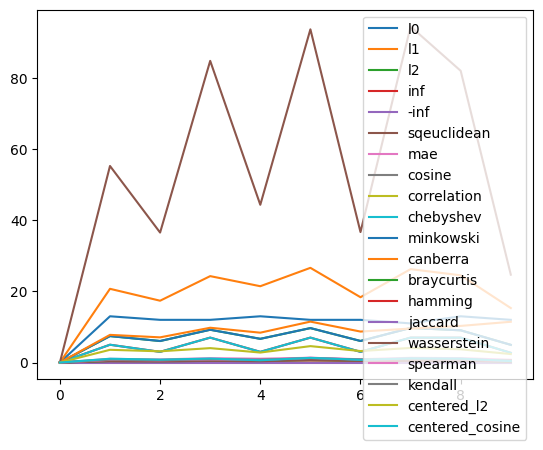

In [11]:
X = splits['X_test'].values[:10]

x = splits['X_test'].values[0]

print("Distance examples:")
for metric in metrics:
        distances = get_distances(X,x, policy=metric)
        print(f"{metric} : {[f'{d:.2f}' for d in distances]}")
        plt.plot(distances, label=metric)
plt.legend()


In [12]:
all_stats = {
    model_name: {
        'distances': {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per sample
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        },
        'probabs': [],      # Keep the original probabs
        'corrects': [],      # Keep original # corrects
        'mean_conf': []  # One value per sample
        
    } for model_name in models.keys()
}
    

In [13]:
def check_res(k):
    """this function return True if the distances related to the model k are already computed"""
    # try if the list containing the mean dists has length > 0
    try:
        return len(all_stats[k]['distances']['l2']['mean']) > 0
    except Exception as e:
        print(e)
        return False
for k in models.keys():
    print(k, "computed?",check_res(k))

random_forest computed? False
mlp computed? False
xgboost computed? False
lgbm computed? False


In [14]:



start = time.time()
for jj,k in enumerate(tqdm(models.keys())):
    not_found = 0
    # load the counterfactuals
    result_folder_path = os.path.join(cf_results,
                        k,
                        dt_name)
    print("looking into the folder ",result_folder_path)
    results = os.listdir(result_folder_path)
    # remove the ones that are not npz
    results = [r for r in results if r.endswith(".npz")]
    # remove those that contains "test" in the name
    results = [r for r in results if "test" not in r]
    # take the most recent using os.path.getmtime
    results = sorted(results,key=lambda x: os.path.getmtime(os.path.join(result_folder_path,x)),reverse=True)
    print("I found",len(results),"files")
    if len(results) > 1:
        for i,f in enumerate(results):
            print(str(i)+")",f)
        # i = input()
        # take the most recent 
        i = 0
        if isinstance(i,int):
            results = [results[i]]
        else:
            results = [results[-1]]
    print("for model",k,"using file",results[-1])

    r = results[-1]
    
    print("checking",r)
    starting2 = time.time()
    # load the counterfactuals most recent using nupy
    cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)#results[0]), allow_pickle=True)
    # cfs is a dictionary with keys "cfs" as the only key (it's an npz file). The value of "cfs" is a np array of dictionaries. The keys of the dictionaries are:, instace_idx (the index of the instance in the calibration set), original_instance (the original class of the instance), true_class (the true class of the instance)
    print(cfs["cfs"].shape[0])
    if check_res(k):
        print("Already computed for model",k)

        continue
    probabs = []
    corrects = []
    confs = []
    # cfs = {"cfs":np.arange(200)}
    
    for i in tnrange(cfs["cfs"].shape[0]):
        ## let's see the output for the original instance
        ## and check if the model is predicting the class (even to check what true_class is)
        ## then we can check the counterfactuals and see if the model is predicting the opposite class
        ## and if it aligns with the "target" attribute of the counterfactuals
        original_instance = cfs["cfs"][i]["original_instance"]
        original_class = cfs["cfs"][i]["true_class"]
        true_cf = cfs["cfs"][i]["counterfactuals"].target.values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        correct = original_class == pred

        good_cfs = cfs["cfs"][i]["counterfactuals"].values[:,:-1]
        good_cfs = good_cfs[true_cf != pred]
        true_cf = true_cf[true_cf != pred]
        if len (good_cfs) > 0:
            mean_confidences_cfs = models[k].predict_proba(good_cfs).mean(axis=0)
        else:
            mean_confidences_cfs = np.array([np.nan,np.nan])
        for metric in metrics:
            if len(true_cf) == 0:
                distancies = np.array([np.inf])
                #print("NOT FOUND COUNTERFACTUALS FOR SAMPLE",i)
                not_found+=1
            else:
                assert (true_cf-true_cf.mean() == 0).all(), "The counterfactuals are not aligned with the target"+str(true_cf)
                #distancies = np.linalg.norm(good_cfs - cfs["cfs"][i]["original_instance"].values,axis=1)
                distancies = get_distances(good_cfs, cfs["cfs"][i]["original_instance"].values,
                                        policy=metric)
            
            all_stats[k]['distances'][metric]['min'].append(distancies.min(axis=0))
            all_stats[k]['distances'][metric]['max'].append(distancies.max(axis=0))
            all_stats[k]['distances'][metric]['mean'].append(distancies.mean(axis=0))
            all_stats[k]['distances'][metric]['std'].append(distancies.std(axis=0))
            
        probabs.append(pred_prob)
        corrects.append(correct)
        confs.append(mean_confidences_cfs)
        # print(distancies)
        #if i / 4 < 1:
        #   sns.kdeplot(distancies,cumulative=False,label=str(i)+" "+str(len(distancies))+ " counterfactuals "+k,ax=axs[i])
    all_stats[k]['probabs'] = probabs
    all_stats[k]['corrects'] = corrects
    all_stats[k]['mean_conf'] = confs
    print("For the model ",k,"not found",not_found,"counterfactuals")
    print("Time for model",k,":",time.time()-starting2)


  0%|          | 0/4 [00:00<?, ?it/s]

looking into the folder  counterfactuals/random_forest/german_credit
I found 1 files
for model random_forest using file cf_results_dice_kdtree_20241219_171636.npz
checking cf_results_dice_kdtree_20241219_171636.npz
200


  0%|          | 0/200 [00:00<?, ?it/s]

For the model  random_forest not found 0 counterfactuals
Time for model random_forest : 509.36510276794434
looking into the folder  counterfactuals/mlp/german_credit
I found 1 files
for model mlp using file cf_results_dice_kdtree_20241219_194550.npz
checking cf_results_dice_kdtree_20241219_194550.npz
200


  0%|          | 0/200 [00:00<?, ?it/s]

For the model  mlp not found 0 counterfactuals
Time for model mlp : 512.3107333183289
looking into the folder  counterfactuals/xgboost/german_credit
I found 2 files
0) cf_results_dice_kdtree_20241220_202219.npz
1) cf_results_dice_kdtree_20241219_225952.npz
for model xgboost using file cf_results_dice_kdtree_20241220_202219.npz
checking cf_results_dice_kdtree_20241220_202219.npz
200


  0%|          | 0/200 [00:00<?, ?it/s]

For the model  xgboost not found 1120 counterfactuals
Time for model xgboost : 421.67636919021606
looking into the folder  counterfactuals/lgbm/german_credit
I found 1 files
for model lgbm using file cf_results_dice_kdtree_20241220_020408.npz
checking cf_results_dice_kdtree_20241220_020408.npz
200


  0%|          | 0/200 [00:00<?, ?it/s]

For the model  lgbm not found 0 counterfactuals
Time for model lgbm : 514.1683166027069


In [38]:
for k in models.keys():
    try:
        all_stats[k]['mean_conf'] = np.array(all_stats[k]['mean_conf'])
    except Exception as e:
        for j,el in enumerate(all_stats[k]['mean_conf']):
            if len(el) == 1:
                print("empty")
                print(len(el[0]))
                all_stats[k]['mean_conf'][j]=el[0]



In [39]:
with open("debug/"+dt_name+"ranking_new2.pkl", "wb") as f:
    pickle.dump(all_stats, f)

In [40]:
with open("debug/"+dt_name+"ranking_new2.pkl", "rb") as f:
    all_stats = pickle.load(f)

In [41]:
#

In [42]:

# convert all the list in the dictionary to numpy arrays
for k in models.keys():
    for metric in metrics:
        for stat in ["min", "max", "mean", "std"]:
            try:
                all_stats[k]['distances'][metric][stat] = np.array(all_stats[k]['distances'][metric][stat])
            except Exception as e:
                print(e)
                print(k, metric, stat,len(all_stats[k]['distances'][metric][stat]))
                for e in all_stats[k]['distances'][metric][stat]:
                    print(e)
for k in models.keys():
    all_stats[k]['probabs'] = np.array(all_stats[k]['probabs'])
    all_stats[k]['corrects'] = np.array(all_stats[k]['corrects']).reshape(-1)
    all_stats[k]['mean_conf'] = np.array(all_stats[k]['mean_conf'])

## There is a correlation?
Let's see the correlation between the distances (min, max, mean) and theprobability output of the model.


[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]


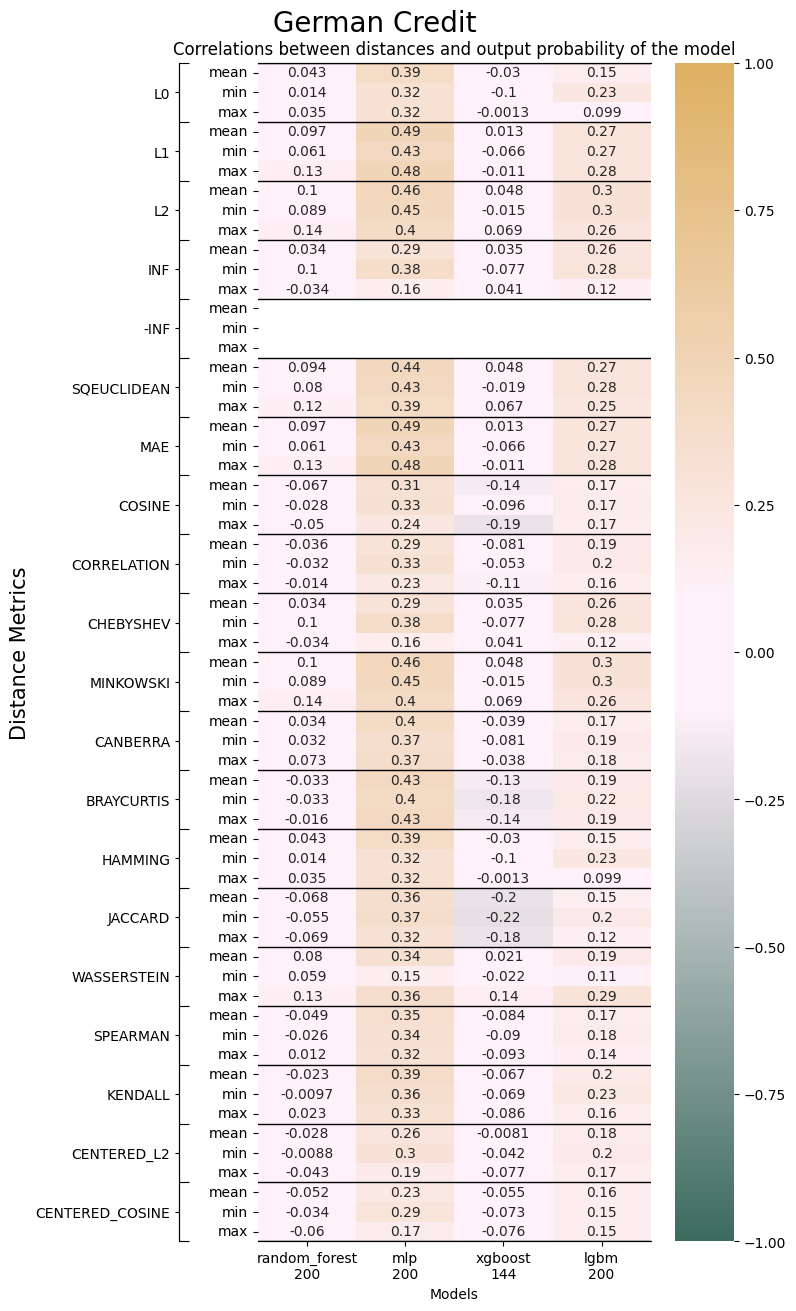

In [43]:

from matplotlib import ticker
# Convert lists to numpy arrays first
verbose = False
correlations = {}
for metric in metrics:
    correlations[metric] = {}
    correlations["found_cfs"]={}
    for k in models.keys():

        mins  = all_stats[k]['distances'][metric]['min'][:200]
        good_idxs = mins != np.inf

        mins = mins[good_idxs]
        maxs  = all_stats[k]['distances'][metric]['max'][:200][good_idxs]
        means = all_stats[k]['distances'][metric]['mean'][:200][good_idxs]
        probs = all_stats[k]['probabs'][:200][good_idxs]

        correlations[metric][k] = {}
        
        correlations[metric][k]["min"] = np.corrcoef(mins, probs.max(axis=1))[0,1]
        
        correlations[metric][k]["max"] = np.corrcoef(maxs, probs.max(axis=1))[0,1]
        correlations[metric][k]["mean"] = np.corrcoef(means, probs.max(axis=1))[0,1]
        if verbose:
            print(f"{metric} correlation for {k}:")
            print("Min", np.round(correlations[metric][k]["min"],3))
            print("Max", np.round(correlations[metric][k]["max"],3))
            print("Mean", np.round(correlations[metric][k]["mean"],3))
            print()
        correlations["found_cfs"][k] = good_idxs.sum()
# Create a bigger matrix for all metrics
# Shape will be (3 * number_of_metrics, number_of_models)
all_correlations = []
for metric in metrics:
    metric_corr = []
    for stat in ["mean", "min", "max"]:
        row = [correlations[metric][model][stat] for model in models.keys()]
        metric_corr.append(row)
    all_correlations.extend(metric_corr)

all_correlations = np.array(all_correlations)

# Create labels for y-axis that include both metric and stat
y_labels = []
for metric in metrics:
    for stat in ["mean", "min", "max"]:
        y_labels.append(f"{stat}")
total_metrics = len(metrics)
rows_per_metric = 3

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, len(metrics)*2/3))
gold_map_r = build_cmap(0.1, '#3c6b5e', '#fff1f9', '#deb062')
sns.heatmap(all_correlations, annot=True, ax=ax, vmin=-1, vmax=1, cmap=gold_map_r)
ax.set_yticklabels(y_labels, rotation=0)
ax.set_xticklabels([model+"\n"+str(correlations["found_cfs"][model]) for model in models.keys()])
ax.set_title("Correlations between distances and output probability of the model")
#plt.ylabel("Distance Metrics")
plt.xlabel("Models")
# Add horizontal lines between metric sections
for i in range(total_metrics + 1):
    ax.axhline(y=i*rows_per_metric, color='black', linewidth=1)

ax_metrics = ax.twinx()
ax_metrics.spines["left"].set_position(("axes", -0.2))
ax_metrics.tick_params('both', length=3, direction='out', which='major')
ax_metrics.yaxis.set_ticks_position("left")
ax_metrics.yaxis.set_label_position("left")

# Set metric positions and labels
metric_positions = [(i * 3 + 1.5) for i in range(len(metrics))]  # Center of each metric section
ax_metrics.set_ylim(ax.get_ylim())
ax_metrics.set_yticks(metric_positions)
ax_metrics.set_yticklabels([m.upper() for m in metrics])
ax_metrics.set_ylabel("Distance Metrics", rotation=90,fontsize=15)

# get anew axis
ax_ = ax.twinx()
ax_.spines["left"].set_position(("axes", -.2))

ax_.tick_params('both', length=7, direction='in', which='major')
ax_.yaxis.set_ticks_position("left")
#ax_.yaxis.set_ticks_position("right")
#ax_.yaxis.set_label_position("right")
ticks_positions = (3*np.arange(0, len(metrics)+1))
ticks_positions=ticks_positions/ticks_positions.max()
print(ticks_positions)
ax_.set_yticks(ticks_positions)
ax_.set_yticklabels([""]*len(metrics)+[""])

ax_.spines["right"].set_visible(False)
ax_metrics.spines["right"].set_visible(False)
plt.suptitle(name_dataset, fontsize=20)
plt.tight_layout()
# save the figure
plt.savefig("plots/Correlations_"+dt_name+"_distances.png")

plt.show()

In [173]:
# let's seek the outliers (if any) by using the iforest algorithm
from sklearn.ensemble import IsolationForest
anomaly_detector = IsolationForest(contamination=0.05)
anomaly_detector.fit(splits["X_train"])
anomalies = anomaly_detector.predict(splits["X_calibration"])<0




In [183]:
# now the plots!
# create 4 subplots

def create_plot_distances(dictionary,
                          sortby="mean",
                          axe=None,
                          title=None,
                          legend=False,colors = {"min":"blue","max":"red","mean":"black"},
                          ylim = None):
    if axe == None:
        axe = plt.gca()

    min_color = colors["min"]
    max_color = colors["max"]
    mean_color = colors["mean"]

    argsorted = dictionary[sortby].argsort()
    rank_m = dictionary["min"][argsorted]
    rank_M = dictionary["max"][argsorted]
    rank_mean = dictionary["mean"][argsorted]
    
    if "correct" in dictionary.keys():
        rank_corrects = dictionary["correct"][argsorted]

        # shade the background with vertical lines colored by the corrects
        # if the model is correct the line is green, otherwise it's red
        # the alpha is 0.2, use axvline to plot the vertical lines
        for i in range(len(rank_corrects)):
            if rank_corrects[i]:
                axe.axvline(i,color="yellow",alpha=0.2)
            else:
                axe.axvline(i,color="purple",alpha=0.2)
        

    axe.fill_between(np.arange(len(rank_m)),rank_m,rank_M,alpha=0.5,label="Min-Max")
    axe.plot(rank_m,alpha=0.5,color=min_color)
    axe.plot(rank_mean,label="Mean",alpha=0.5,color=mean_color)
    axe.plot(rank_M,alpha=0.5,color=max_color)
    #axe.errorbar(np.arange(len(rank_m)),rank_mean,yerr=rank_std,label="Std")
    # plot the "smoothed" values
    axe.plot(np.arange(len(rank_m)),pd.Series(rank_m).rolling(5).mean(),label="Min",color=min_color)
    axe.plot(np.arange(len(rank_mean)),pd.Series(rank_mean).rolling(5).mean(),label="Mean",color=mean_color)
    axe.plot(np.arange(len(rank_M)),pd.Series(rank_M).rolling(5).mean(),label="Max",color=max_color)

    if legend:
        axe.legend(fontsize=15)
    axe.set_xlabel("Distances from cfs sorted by "+sortby,fontsize=15)
    axe.set_ylabel("Distance",fontsize=15)
    if title is not None:
        axe.set_title(title,fontsize=18)
    axe.grid()
    if ylim is not None:
        ylims = axe.get_ylim()

        axe.set_ylim(ylim[0],ylim[1])
        
    if "Predict Proba" in dictionary.keys():
        ax2 = axe.twinx()
        rank_prob = dictionary["Predict Proba"][argsorted]
        ax2.plot(np.arange(len(rank_m)),rank_prob,label="Probability",color="black",linestyle="--")
        ax2.set_ylim(0,1)
        ax2.set_ylabel("Probability",fontsize=15,rotation=270)
        if legend:
            # location is lower right
            ax2.legend(fontsize=15,loc="lower right")

        # get another x axes
    else:
        ax2 = axe.twiny()
        # place some ticks x shaped in correspondence of the anomalies
    
    ax2.scatter(np.arange(len(rank_m))[anomalies[argsorted]],
                 0.05*np.ones(anomalies.sum()),
                 marker="x",color="black",label="Anomalies")

    axe.set_title(sortby)
    five_perc = int(len(rank_m)*0.05)
    axe.set_xlim([-five_perc,len(rank_m)+five_perc])
    axe.xaxis.set_tick_params(labelsize=15)
    axe.yaxis.set_tick_params(labelsize=15)
    # tight layout
    plt.tight_layout()
    return axe



for metric in ["l0","l1","l2",
               "sqeuclidean",
               "mae","minkowski"]:
    fig, axs = plt.subplots(4, 4, figsize=(20, 20))
    axs = axs.flatten()
    # each model goes in a different subplot
    # we plot the sorted values of the minimum and the maximum distances,
    # then we shade the area between them. On top of that we plot the mean
    # at each data point we plot a vertical line with the std value of the distances, centeed at the mean
    c=0
    max_ = np.max([pd.Series(all_stats[k]["distances"][metric]["max"][
                   pd.Series(all_stats[k]["distances"][metric]["max"]).apply(np.isfinite)
                             ]).max(skipna=True)
                   for k in models.keys()])
    min_ = np.min([pd.Series(all_stats[k]["distances"][metric]["min"][
                   pd.Series(all_stats[k]["distances"][metric]["min"]).apply(np.isfinite)
                             ]).min(skipna=True)
                   for k in models.keys()])
    
    data_range = max_ - min_
    #make the the max_ylim so that the max value goes at the 67% of the plot
    max_ylim = max_ + (data_range * 0.33)  # Add 33% of range above max
    min_ylim = min_ - (data_range * 0.1)   # Subtract 10% of range below min
    #max_ylim = min(20,max_ylim)
    #min_ylim = max(0,min_ylim)
    print("max",max_,"min",min_,"max_ylim",max_ylim,"min_ylim",min_ylim)
    for name in ["Predict Proba"]+["mean","min","max"]:
        for k in models.keys():
            create_plot_distances(dictionary={
                                    "mean":all_stats[k]["distances"][metric]["mean"],
                                    "std":all_stats[k] ["distances"][metric]["std"],
                                    "min":all_stats[k] ["distances"][metric]["min"],
                                    "max":all_stats[k] ["distances"][metric]["max"],
                                    "Predict Proba":all_stats[k]["probabs"].max(axis=1),
                                    "correct":all_stats[k]["corrects"]
                                    },
                            sortby=name,
                            axe=axs[c],
                            title="model is "+k,
                            legend=(True if c==0 else False ),#%4== 0 else False),
                            ylim = (min_ylim,max_ylim))
            c+=1
    date = time.strftime("%Y-%m-%d")
    plt.suptitle(name_dataset+" - "+metric.upper(),fontsize=20)
    plt.tight_layout()
    plt.savefig(os.path.join("plots",
                            "counterfactuals_dice_"+dt_name+"_"+date+"_"+metric+".pdf")
            )
    plt.clf()

max 17.0 min 7.0 max_ylim 20.3 min_ylim 6.0
max 28.807161312628892 min 1.7938716279514728 max_ylim 37.72154690857244 min_ylim -0.9074573405162694
max 11.136552512298504 min 1.137187406769718 max_ylim 14.436342997123004 min_ylim 0.1372508962168394
max 124.02280185918211 min 1.2931951981156364 max_ylim 164.52357205733404 min_ylim -10.979765467991012
max 1.4403580656314445 min 0.08969358139757364 max_ylim 1.886077345428622 min_ylim -0.045372867025813446
max 11.136552512298504 min 1.137187406769718 max_ylim 14.436342997123004 min_ylim 0.1372508962168394


<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

## Visualization
We will use a scatter plot to visualize the correlation between the distances and the probability output of the model.

In [67]:

# Example usage
class_labels = ["Class 0","Class 1"]

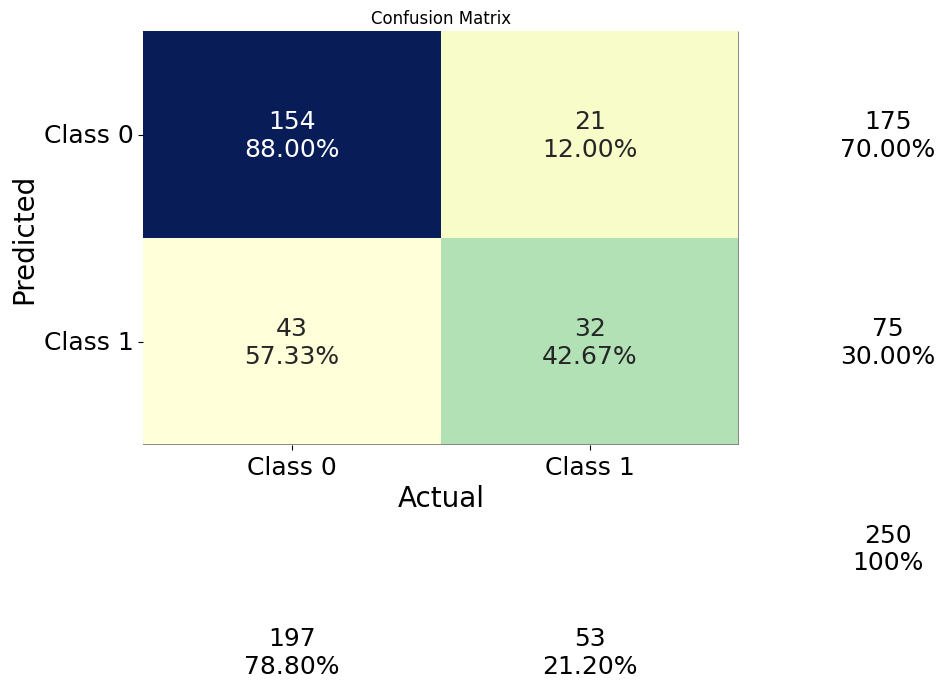

In [68]:
y_test = splits['y_test']
X_test = splits['X_test']
y_pred = models["mlp"].predict(X_test)

from src.fancy_plots import plot_confusion_matrix
plot_confusion_matrix(y_test, y_pred, class_labels=class_labels,cmap='YlGnBu')

In [112]:
# now we do cool thing. We train a BernulliRBM to have a projection of the data in a two dimentional space (using the train split.)
# we then use the RBM to map 2d points to the original space and we plot the decision boundary of the original points but in the 2d space
# we then take few examples and we plot the counterfactuals in the 2d space. The few examples are the one with the smallest distance, the one with the largest distance, the one with a mid distance... 

from sklearn.neural_network import BernoulliRBM
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



mapper_ = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('mapper', PCA(n_components=2)),#('rbm', BernoulliRBM(n_components=2, n_iter=100, random_state=0)),
    #('classifier', LogisticRegression(random_state=0))
])

mapper_.fit(splits['X_train'], splits['y_train'])

mapped_X = mapper_.transform(splits['X_test'])
mapped_X.shape

(250, 2)

In [158]:
class RBMInverseTransformer:
    def __init__(self, rbm):
        self.rbm = rbm

    def transform(self, X_transformed):
        """Approximate the inverse using RBM's weights and biases."""
        hidden_to_visible_weights = self.rbm.components_.T
        visible_bias = self.rbm.intercept_visible_

        # Perform the inverse transformation (logistic approximation)
        X_reconstructed = X_transformed @ hidden_to_visible_weights.T + visible_bias
        return X_reconstructed
    
inverse_mapper = Pipeline(steps=[
    ('imapper_', RBMInverseTransformer(mapper_.named_steps['mapper'])),
    #('inverse_scaler', mapper_rbm.named_steps['scaler'])
])

# Define the inverse PCA mapper
class InversePCAMapper:
    def __init__(self, scaler, pca):
        self.scaler = scaler
        self.pca = pca

    def transform(self, X_transformed):
        """
        Inverse the PCA transformation to map back to original scaled space.
        """
        # Inverse PCA to get back to scaled space
        X_scaled = self.pca.inverse_transform(X_transformed)
        # Inverse scaling to get back to the original space
        return self.scaler.inverse_transform(X_scaled)

inverse_pca = InversePCAMapper(scaler=mapper_.named_steps['scaler'], pca=mapper_.named_steps['mapper'])

inverse_mapper = inverse_pca



In [152]:
wrapped_model.predict(X_train_2d).shape, splits['y_train'].shape
(wrapped_model.predict(X_train_2d)==models["random_forest"].predict(splits['X_train'])).sum()

385

In [185]:
def load_cf(k):
    result_folder_path = os.path.join(cf_results,
                        k,
                        dt_name)
    results = os.listdir(result_folder_path)
    # remove the ones that are not npz
    results = [r for r in results if r.endswith(".npz")]
    # remove those that contains "test" in the name
    results = [r for r in results if "test" not in r]
    # take the most recent using os.path.getmtime
    results = sorted(results,key=lambda x: os.path.getmtime(os.path.join(result_folder_path,x)),reverse=True)
    print("I found",len(results),"files")
    if len(results) > 1:
        for i,f in enumerate(results):
            print(str(i)+")",f)
        # i = input()
        # take the most recent 
        i = 0
        if isinstance(i,int):
            results = [results[i]]
        else:
            results = [results[-1]]
    print("for model",k,"using file",results[-1])

    r = results[-1]
    
    print("checking",r)
    starting2 = time.time()
    # load the counterfactuals most recent using nupy
    cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)
    return cfs

In [186]:
X_train_2d = mapper_.transform(splits['X_train'])
X_cal_2d = mapper_.transform(splits['X_calibration'])


2025-01-22 18:59:38,403 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 1 files
for model random_forest using file cf_results_dice_kdtree_20241219_171636.npz
checking cf_results_dice_kdtree_20241219_171636.npz


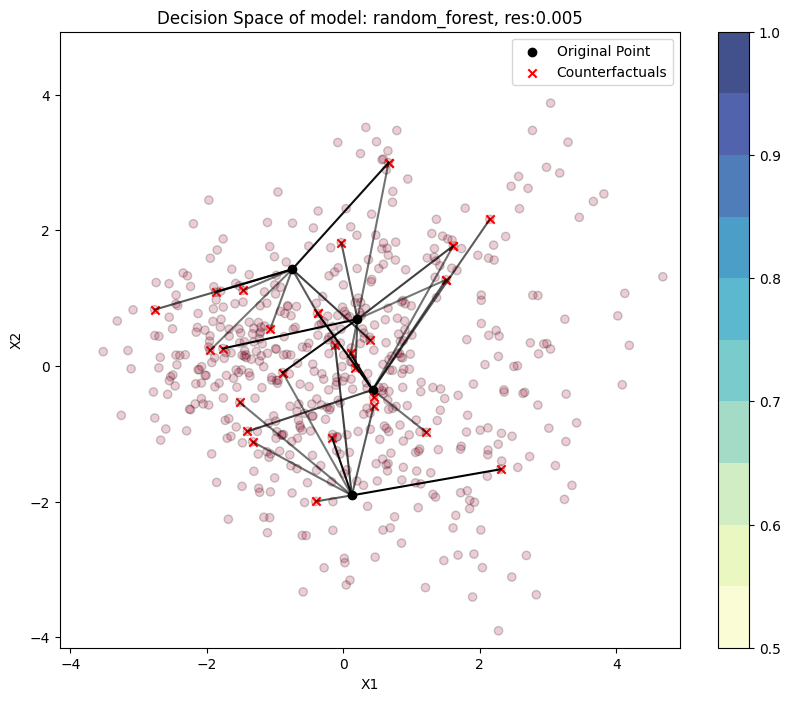

2025-01-22 18:59:43,739 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 1 files
for model mlp using file cf_results_dice_kdtree_20241219_194550.npz
checking cf_results_dice_kdtree_20241219_194550.npz


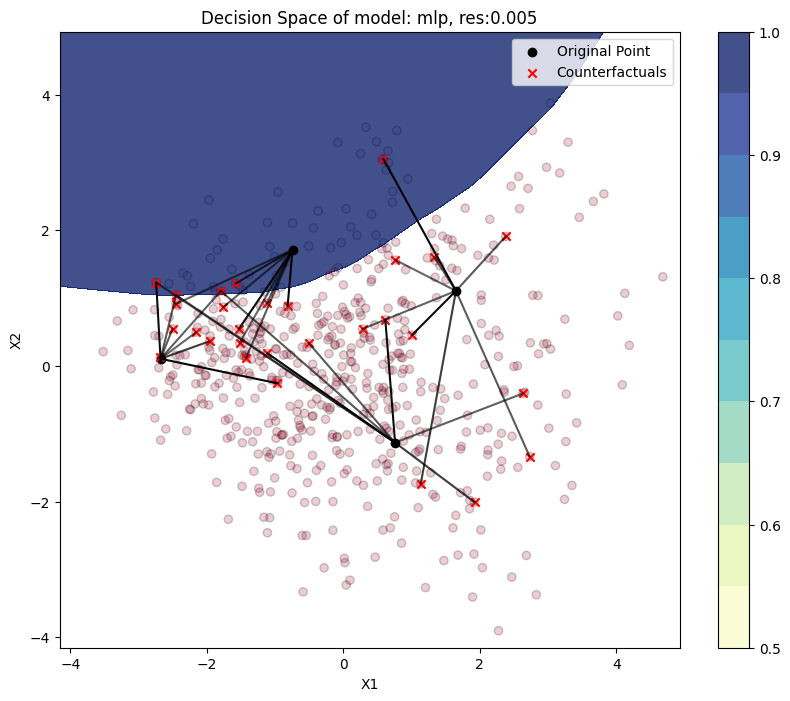

2025-01-22 18:59:51,151 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 2 files
0) cf_results_dice_kdtree_20241220_202219.npz
1) cf_results_dice_kdtree_20241219_225952.npz
for model xgboost using file cf_results_dice_kdtree_20241220_202219.npz
checking cf_results_dice_kdtree_20241220_202219.npz
NOT FOUND COUNTERFACTUALS FOR SAMPLE 80


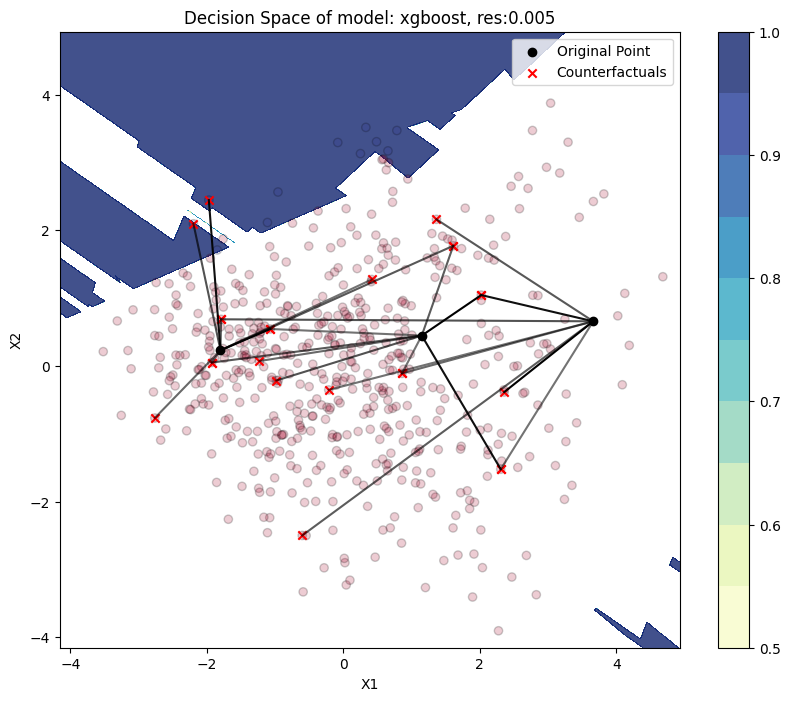

2025-01-22 18:59:57,749 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 1 files
for model lgbm using file cf_results_dice_kdtree_20241220_020408.npz
checking cf_results_dice_kdtree_20241220_020408.npz


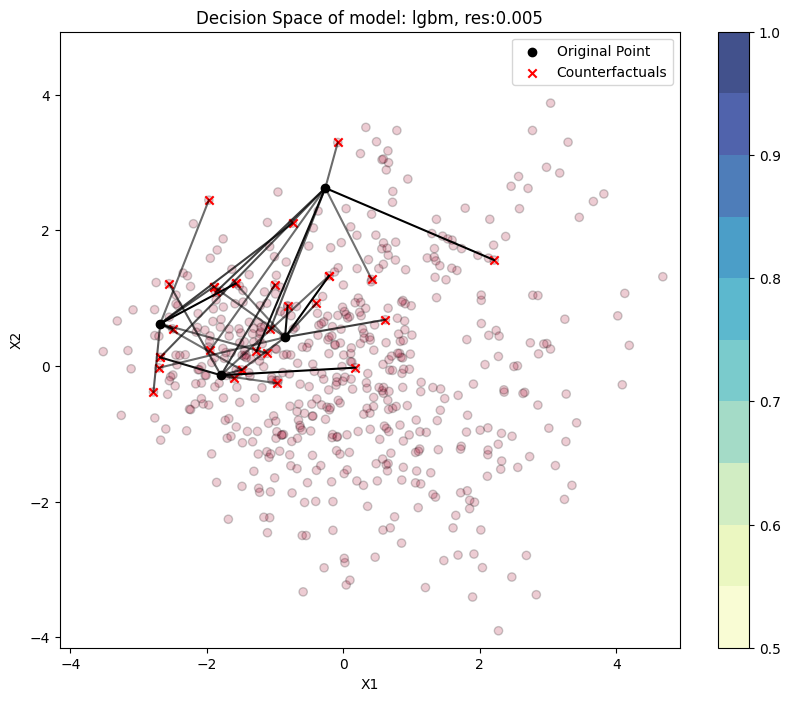

In [203]:

def plot_decision_space(my_model,model_name='',
                        draw_confidence=True,
                        X=None,y=None,
                        res = 0.01):
    """
        This funciton is used to plot the decision space of a model
    """
    x_min, x_max = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
    y_min, y_max = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
    x_max = y_max = max(x_max,y_max)
    y_min = x_min = min(x_min,y_min)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, res),
                            np.arange(y_min, y_max, res))

    if draw_confidence:
        Z = np.max(my_model.predict_proba(np.c_[xx.ravel(), yy.ravel()]),axis=1)
    else:
        Z = my_model.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(10, 8))
    cmap = plt.cm.RdYlBu.reversed()
    cmap = plt.cm.YlGnBu
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=cmap,vmax=1.0,vmin=0.5,levels=np.linspace(0.5,1,11))
    plt.colorbar()
    # for the legend use the shaded color and the class labels: "predicted class i"
    #for i in range(0, len(set(y))):
    #    plt.scatter([], [], s=100, label="Class "+str(i),color=plt.cm.RdYlBu(i/len(set(y))),vmin=0,vmax=1)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='black',vmin=0,vmax=1,alpha=0.2)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    if len(model_name)>0:
        model_name = ": "+str(model_name)+ ", res:"+str(res)
    plt.title('Decision Space of model'+str(model_name))
    return plt.gca()

# the wrapper model takes as input the 2d points and returns the prediction of the model
# as the models in the models dictionary takes as input the original space, the initial step of the wrapper model is the inverse of the RBM
# the second step is the model itself
# inverse_rbm is the pipeline that takes the 2d points and returns the original space points
for k in models.keys():
    wrapped_model = Pipeline(steps=[ # recreate now step by step the pipeline
        #("inverse_scaler", inverse_mapper.named_steps["scaler"]),
        ("inverse_mapper", inverse_mapper),
        #('scaler', models["mlp"].named_steps['scaler']),
        ('model', models[k].named_steps['model'])

    ])
    wrapped_model.predict(mapped_X)

    ax = plot_decision_space(wrapped_model,model_name=k,
                        X = X_train_2d,y = wrapped_model.predict(X_train_2d),
                        res=.005,
                        draw_confidence=False)
    
    # select 10 random samples from the calibration set
    # plot the samples and the counterfactuals in the 2d space
    # for each sample plot a line that connects it with its counterfactuals
    # the line is colored by the distance of the counterfactuals 
    cfs = load_cf(k)
    choosen_samples_ = np.random.choice(range(cfs["cfs"].shape[0]),4)
    
        
    for i in choosen_samples_:
        ## let's see the output for the original instance
        ## and check if the model is predicting the class (even to check what true_class is)
        ## then we can check the counterfactuals and see if the model is predicting the opposite class
        ## and if it aligns with the "target" attribute of the counterfactuals
        original_instance = cfs["cfs"][i]["original_instance"].values
        original_class = cfs["cfs"][i]["true_class"]
        true_cf = cfs["cfs"][i]["counterfactuals"].target.values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        correct = original_class == pred
        
        good_cfs = cfs["cfs"][i]["counterfactuals"].values[:,:-1]
        good_cfs = good_cfs[true_cf != pred]
        true_cf = true_cf[true_cf != pred]
        if len (good_cfs) == 0:
            print("NOT FOUND COUNTERFACTUALS FOR SAMPLE",i)
            continue
            
        # plot the tranformed original point
        
        original_point = mapper_.transform(original_instance)[0]
        ax.scatter(original_point[0],original_point[1],color="black",marker="o")
        # plot the counterfactuals
        
        widths = all_stats[k]["distances"]["l2"]["mean"]
        widths = np.array(widths)
        widths = widths[widths != np.inf]
        widths = (widths-widths.min())/(widths.max()-widths.min())
        widths = (widths*0.5)+0.5
        for j in range(len(good_cfs)):
            cf = good_cfs[j]
            cf_point = mapper_.transform(cf.reshape(1,-1))[0]
            # plot the line connecting the two points
            # the width is proportional to the distance in the original space
            # the distance is the l2 norm

            ax.plot([original_point[0],cf_point[0]],[original_point[1],cf_point[1]],alpha=widths[j],color="black")
            # plot the point
            ax.scatter(cf_point[0],cf_point[1],color="red",marker="x")

        # get the x and y limits
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()
    # plot a single point for the legend
    ax.scatter([],[],color="black",marker="o",label="Original Point")
    ax.scatter([],[],color="red",marker="x",label="Counterfactuals")
    plt.legend()
    plt.show()


In [ ]:
plot_decision_space(clf)
print(f1_score(y_test, y_pred, average='weighted'))